<a href="https://colab.research.google.com/github/iMba-I/Labs/blob/main/Lab3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN

In [31]:
import numpy as np
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch.nn.functional as F
import torch

np.random.seed(42)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(x):
    return np.maximum(0, x)

def softmax(z):
    exp = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

def activation_fun(x, act_type='relu'):
    if act_type == 'relu':
        return relu(x)
    elif act_type == 'sigmoid':
        return sigmoid(x)
    elif act_type == 'softmax':
        return softmax(x)
    else:
        raise ValueError(f"Unknown activation type: {act_type}")

def conv2d(X, W, b, stride=1, padding=0):
    """
    X: (N, C_in, H, W)
    W: (C_out, C_in, k, k)
    b: (C_out,)
    """
    N, C_in, H, W_in = X.shape
    C_out, _, k, _ = W.shape

    # Padding
    if padding > 0:
        X_padded = np.pad(
            X,
            ((0,0), (0,0), (padding,padding), (padding,padding)),
            mode='constant'
        )
    else:
        X_padded = X

    H_out = (H - k + 2 * padding) // stride + 1
    W_out = (W_in - k + 2 * padding) // stride + 1

    out = np.zeros((N, C_out, H_out, W_out))

    for n in range(N):
        for c_out in range(C_out):
            for i in range(H_out):
                for j in range(W_out):
                    h_start = i * stride
                    w_start = j * stride
                    window = X_padded[n, :, h_start:h_start+k, w_start:w_start+k]
                    out[n, c_out, i, j] = np.sum(window * W[c_out]) + b[c_out]

    return out


def max_pool(X, size=2, stride=2):
    """
    X: (N, C, H, W)
    """
    N, C, H, W = X.shape
    H_out = (H - size) // stride + 1
    W_out = (W - size) // stride + 1

    out = np.zeros((N, C, H_out, W_out))

    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    h_start = i * stride
                    w_start = j * stride
                    window = X[n, c, h_start:h_start+size, w_start:w_start+size]
                    out[n, c, i, j] = np.max(window)

    return out

def flatten(X):
    return X.reshape(X.shape[0], -1)




class NeuralNetwork_CNN:
    def __init__(self, input_shape, conv_arch, fc_arch, output_size=1, classif_type='bin'):
        """
        input_shape: tuple (C, H, W)
        conv_arch: list of dicts, each dict: {'filters': int, 'kernel_size': int, 'stride': int, 'padding': int, 'pool': bool}
        fc_arch: list of ints, количество нейронов в полносвязных слоях
        output_size: количество выходов (1 для бинарной классификации)
        classif_type: 'bin' или 'multi'
        """
        self.classif_type = classif_type
        self.conv_arch = conv_arch
        self.fc_arch = fc_arch

        self.C, self.H, self.W = input_shape

        # Инициализация весов сверточных слоёв
        self.conv_weights = []
        self.conv_biases = []

        in_channels = self.C
        H_current, W_current = self.H, self.W

        for layer in conv_arch:
            out_channels = layer['filters']
            k = layer['kernel_size']
            stride = layer.get('stride', 1)
            padding = layer.get('padding', 0)

            # Инициализация весов (C_out, C_in, k, k)
            W_conv = np.random.randn(out_channels, in_channels, k, k) * np.sqrt(2. / (in_channels * k * k))
            b_conv = np.zeros((out_channels,))
            self.conv_weights.append(W_conv)
            self.conv_biases.append(b_conv)

            # Рассчёт выходных размеров после свёртки
            H_current = (H_current - k + 2*padding) // stride + 1
            W_current = (W_current - k + 2*padding) // stride + 1

            # Если указан max pooling, обновим размеры
            if layer.get('pool', False):
                pool_size = 2
                pool_stride = 2
                H_current = (H_current - pool_size) // pool_stride + 1
                W_current = (W_current - pool_size) // pool_stride + 1

            in_channels = out_channels

        # Размер входа в первый FC слой после flatten
        fc_input_size = in_channels * H_current * W_current

        # Инициализация весов полносвязных слоёв
        layer_sizes = [fc_input_size] + fc_arch + [output_size]
        self.L = len(layer_sizes) - 1

        self.fc_weights = []
        self.fc_biases = []
        for i in range(self.L):
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2. / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.fc_weights.append(W)
            self.fc_biases.append(b)

        # Для мониторинга
        self.train_loss = []
        self.val_loss = []
        self.test_loss = []
        self.test_acc = []
        self.train_acc = []
        self.val_acc = []
        self.y_pred_check = []

    def forward(self, X):
        """
        X: (N, C, H, W)
        """
        N = X.shape[0]

        # Свёрточные слои
        A = X
        conv_activations = [A]
        for i, layer in enumerate(self.conv_arch):
            W = self.conv_weights[i]
            b = self.conv_biases[i]
            stride = layer.get('stride', 1)
            padding = layer.get('padding', 0)
            A = conv2d(A, W, b, stride=stride, padding=padding)
            A = relu(A)
            if layer.get('pool', False):
                A = max_pool(A, size=2, stride=2)
            conv_activations.append(A)

        # Flatten для перехода к FC слоям
        A = flatten(A)

        # Полносвязные слои
        zs = []
        activations = [A]
        for i in range(self.L):
            Z = A @ self.fc_weights[i] + self.fc_biases[i]
            zs.append(Z)
            if i != self.L - 1:
                A = relu(Z)
            else:
                if self.classif_type == 'bin':
                    A = sigmoid(Z)
                else:
                    A = softmax(Z)
            activations.append(A)

        return A, zs, activations, conv_activations


    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        if self.classif_type == 'bin':

            eps = 1e-15
            y_pred = np.clip(y_pred, eps, 1 - eps)
            loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
            print(loss,y_pred,y_true)

        else:

            eps = 1e-15
            y_pred = np.clip(y_pred, eps, 1 - eps)
            loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        return loss

    def backward(self, X_np, y_true_np, lr):
        """
        X_np: входные данные (numpy), размер (N, C, H, W)
        y_true_np: истинные метки (numpy), для бинарной - (N,), для мульти - one-hot (N, num_classes)
        lr: learning rate
        """

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # --- Переводим параметры в PyTorch тензоры с requires_grad=True ---
        conv_weights_t = [torch.tensor(w, dtype=torch.float32, device=device, requires_grad=True) for w in self.conv_weights]
        conv_biases_t = [torch.tensor(b, dtype=torch.float32, device=device, requires_grad=True) for b in self.conv_biases]

        fc_weights_t = [torch.tensor(w, dtype=torch.float32, device=device, requires_grad=True) for w in self.fc_weights]
        fc_biases_t = [torch.tensor(b, dtype=torch.float32, device=device, requires_grad=True) for b in self.fc_biases]

        # --- Преобразуем входные данные и метки в тензоры ---
        X = torch.tensor(X_np, dtype=torch.float32, device=device)

        if self.classif_type == 'bin':
            y_true = torch.tensor(y_true_np, dtype=torch.float32, device=device).view(-1, 1)
        else:
            y_true = torch.tensor(y_true_np, dtype=torch.float32, device=device)

        # --- Forward pass в PyTorch ---
        A = X
        for i, layer in enumerate(self.conv_arch):
            W = conv_weights_t[i]
            b = conv_biases_t[i]

            stride = layer.get('stride', 1)
            padding = layer.get('padding', 0)
            pool = layer.get('pool', False)

            A = F.conv2d(A, W, bias=b, stride=stride, padding=padding)
            A = F.relu(A)
            if pool:
                A = F.max_pool2d(A, kernel_size=2, stride=2)

        A = A.view(A.size(0), -1)  # flatten

        for i in range(len(self.fc_weights)):
            W = fc_weights_t[i]
            b = fc_biases_t[i].view(-1)  # b shape (1, out) -> (out,)
            A = A @ W + b
            if i != len(self.fc_weights) - 1:
                A = F.relu(A)

        # Последний слой — активация
        if self.classif_type == 'bin':
            y_pred = torch.sigmoid(A)
            loss_fn = torch.nn.BCELoss()
        else:
            y_pred = F.softmax(A, dim=1)
            loss_fn = torch.nn.CrossEntropyLoss()

        # --- Вычисление функции потерь ---
        if self.classif_type == 'bin':
            loss = loss_fn(y_pred, y_true)
        else:
            # Для CrossEntropyLoss нужен индекс класса, а не one-hot
            y_true_cls = torch.argmax(y_true, dim=1)
            loss = loss_fn(A, y_true_cls)

        # --- Обратный проход ---
        loss.backward()

        # --- Обновление параметров вручную ---
        with torch.no_grad():
            for i in range(len(self.conv_weights)):
                conv_weights_t[i] -= lr * conv_weights_t[i].grad
                conv_biases_t[i] -= lr * conv_biases_t[i].grad

                # Обнуляем градиенты после обновления
                conv_weights_t[i].grad.zero_()
                conv_biases_t[i].grad.zero_()

            for i in range(len(self.fc_weights)):
                fc_weights_t[i] -= lr * fc_weights_t[i].grad
                fc_biases_t[i] -= lr * fc_biases_t[i].grad

                fc_weights_t[i].grad.zero_()
                fc_biases_t[i].grad.zero_()

        # --- Копируем обновленные параметры обратно в numpy-массивы ---
        for i in range(len(self.conv_weights)):
            self.conv_weights[i][:] = conv_weights_t[i].detach().cpu().numpy()
            self.conv_biases[i][:] = conv_biases_t[i].detach().cpu().numpy()

        for i in range(len(self.fc_weights)):
            self.fc_weights[i][:] = fc_weights_t[i].detach().cpu().numpy()
            self.fc_biases[i][:] = fc_biases_t[i].detach().cpu().numpy()


        return loss.item()


    def update_params(self, grads_W, grads_b, lr):
        for i in range(self.L):
            self.weights[i] -= lr * grads_W[i]
            self.biases[i]  -= lr * grads_b[i]

    def predict(self, X):
      y_pred, _, _, _ = self.forward(X)
      if self.classif_type == 'bin':
          return (y_pred > 0.5).astype(int).ravel()
      else:
          return np.argmax(y_pred, axis=1)


    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


    def fit(self, X_train, y_train, X_val, y_val, X_test, y_test,
        lr=0.01, epochs=100, batch_size=32):

      m = X_train.shape[0]

      for epoch in range(1, epochs + 1):
          perm = np.random.permutation(m)
          X_shuffled = X_train[perm]
          y_shuffled = y_train[perm]

          epoch_loss = 0.0
          num_batches = 0

          for start in range(0, m, batch_size):
              end = min(start + batch_size, m)
              xb = X_shuffled[start:end]
              yb = y_shuffled[start:end]

              # Прямой проход numpy (можно опустить, если не нужен для обучения)
              # y_pred, zs, activations, conv_activations = self.forward(xb)

              # Обратный проход и обновление через PyTorch
              loss = self.backward(xb, yb, lr)
              epoch_loss += loss
              num_batches += 1

          # ---------------- TRAIN METRICS ----------------
          y_train_pred_prob, _, _, _ = self.forward(X_train)
          train_loss = self.compute_loss(y_train, y_train_pred_prob)
          y_train_pred = self.predict(X_train)

          if self.classif_type == 'bin':
              train_acc = accuracy_score(y_train, y_train_pred)
          else:
              train_acc = accuracy_score(np.argmax(y_train, axis=1), y_train_pred)

          # ---------------- VAL METRICS ----------------
          y_val_pred_prob, _, _, _ = self.forward(X_val)
          val_loss = self.compute_loss(y_val, y_val_pred_prob)
          y_val_pred = self.predict(X_val)

          if self.classif_type == 'bin':
              val_acc = accuracy_score(y_val, y_val_pred)
          else:
              val_acc = accuracy_score(np.argmax(y_val, axis=1), y_val_pred)

          # ---------------- TEST METRICS ----------------
          y_test_pred_prob, _, _, _ = self.forward(X_test)
          self.y_pred_check.append(y_test_pred_prob)
          test_loss = self.compute_loss(y_test, y_test_pred_prob)
          y_test_pred = self.predict(X_test)

          if self.classif_type == 'bin':
              test_acc = accuracy_score(y_test, y_test_pred)
              test_precision = precision_score(y_test, y_test_pred)
              test_recall = recall_score(y_test, y_test_pred)
              test_f1 = f1_score(y_test, y_test_pred)
          else:
              y_test_true = np.argmax(y_test, axis=1)
              test_acc = accuracy_score(y_test_true, y_test_pred)
              test_precision = precision_score(y_test_true, y_test_pred, average='macro')
              test_recall = recall_score(y_test_true, y_test_pred, average='macro')
              test_f1 = f1_score(y_test_true, y_test_pred, average='macro')

          # Save history
          self.train_loss.append(train_loss)
          self.val_loss.append(val_loss)
          self.test_loss.append(test_loss)
          self.test_acc.append(test_acc)
          self.train_acc.append(train_acc)
          self.val_acc.append(val_acc)

          # Print every 10 epochs
          if epoch % 10 == 0 or epoch == 1:
              print(f"Epoch {epoch}: "
                    f"Train loss={train_loss:.4f}, Val loss={val_loss:.4f}, "
                    f"Train acc={train_acc:.4f}, Val acc={val_acc:.4f} | "
                    f"Test loss={test_loss:.4f}, Test acc={test_acc:.4f}, "
                    f"P={test_precision:.4f}, R={test_recall:.4f}, F1={test_f1:.4f}")





Train shape: (1257, 1, 8, 8), (1257, 10)
Val shape: (270, 1, 8, 8), (270, 10)
Test shape: (270, 1, 8, 8), (270, 10)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1: Train loss=2.2956, Val loss=2.3308, Train acc=0.0931, Val acc=0.0926 | Test loss=2.2912, Test acc=0.1037, P=0.1868, R=0.1047, F1=0.0858
Epoch 10: Train loss=1.5186, Val loss=1.5756, Train acc=0.6555, Val acc=0.6000 | Test loss=1.4992, Test acc=0.6630, P=0.6968, R=0.6612, F1=0.6328
Epoch 20: Train loss=0.7568, Val loss=0.8441, Train acc=0.8345, Val acc=0.7926 | Test loss=0.7235, Test acc=0.8556, P=0.8514, R=0.8540, F1=0.8469
Epoch 30: Train loss=0.4314, Val loss=0.5177, Train acc=0.8966, Val acc=0.8481 | Test loss=0.4134, Test acc=0.8926, P=0.8945, R=0.8920, F1=0.8912
Epoch 40: Train loss=0.2830, Val loss=0.3804, Train acc=0.9284, Val acc=0.8815 | Test loss=0.2831, Test acc=0.9444, P=0.9461, R=0.9440, F1=0.9432
Epoch 50: Train loss=0.2138, Val loss=0.3212, Train acc=0.9475, Val acc=0.8778 | Test loss=0.2345, Test acc=0.9370, P=0.9437, R=0.9365, F1=0.9373


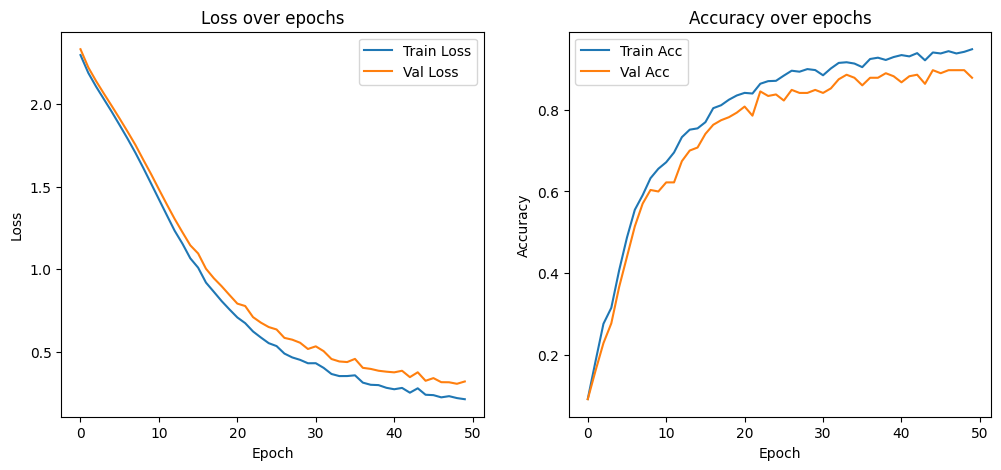

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.76      0.93      0.83        27
           2       1.00      1.00      1.00        27
           3       0.90      0.96      0.93        28
           4       1.00      0.89      0.94        27
           5       0.96      1.00      0.98        27
           6       0.93      0.93      0.93        27
           7       0.93      1.00      0.96        27
           8       1.00      0.81      0.89        26
           9       0.96      0.85      0.90        27

    accuracy                           0.94       270
   macro avg       0.94      0.94      0.94       270
weighted avg       0.94      0.94      0.94       270



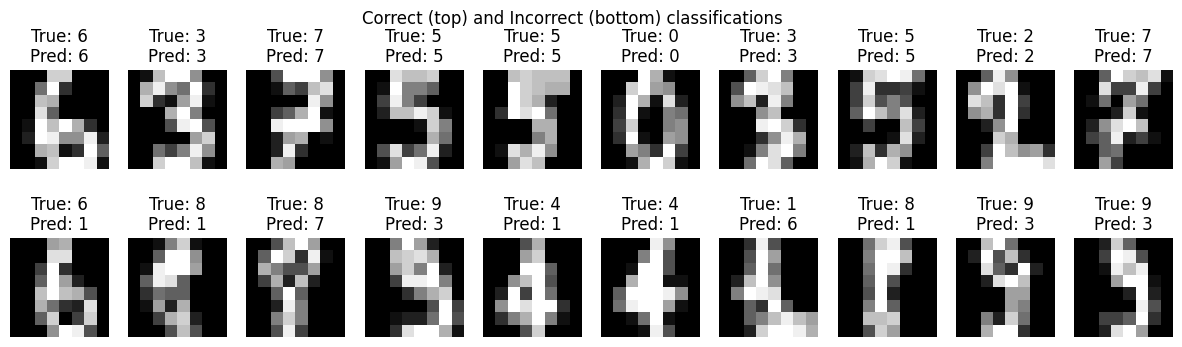

In [32]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
digits = load_digits()
X = digits.images  # форма (1797, 8, 8)
y = digits.target  # shape (1797,)

# Нормализация в диапазон [0,1]
X = X.astype(np.float32) / 16.0  # максимальное значение пикселя 16

# Добавляем размерность канала (C=1) для сверточной сети
X = X[:, np.newaxis, :, :]  # теперь (1797, 1, 8, 8)

# One-hot кодирование меток
encoder = OneHotEncoder(sparse_output=False)  # создаём объект энкодера
y_onehot = encoder.fit_transform(y.reshape(-1, 1))  # применяем к меткам

# Разбиение на train, val, test (например 70% train, 15% val, 15% test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_onehot, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=np.argmax(y_train_val, axis=1))


print(f"Train shape: {X_train.shape}, {y_train.shape}")
print(f"Val shape: {X_val.shape}, {y_val.shape}")
print(f"Test shape: {X_test.shape}, {y_test.shape}")

conv_arch = [
    {'filters': 8, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'pool': True},
    {'filters': 16, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'pool': True}
]

fc_arch = [64]

model = NeuralNetwork_CNN(
    input_shape=(1, 8, 8),
    conv_arch=conv_arch,
    fc_arch=fc_arch,
    output_size=10,
    classif_type='multi'
)


model.fit(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    lr=0.01,
    epochs=50,
    batch_size=64
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model.train_loss, label='Train Loss')
plt.plot(model.val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over epochs')

plt.subplot(1, 2, 2)
plt.plot(model.train_acc, label='Train Acc')
plt.plot(model.val_acc, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')

plt.show()

y_test_pred = model.predict(X_test)
y_test_true = np.argmax(y_test, axis=1)

from sklearn.metrics import classification_report
print(classification_report(y_test_true, y_test_pred))

def plot_examples(X, y_true, y_pred, num_examples=10):
    correct_idx = np.where(y_true == y_pred)[0]
    wrong_idx = np.where(y_true != y_pred)[0]

    plt.figure(figsize=(15, 4))

    # Правильные примеры
    for i, idx in enumerate(correct_idx[:num_examples]):
        plt.subplot(2, num_examples, i+1)
        plt.imshow(X[idx][0], cmap='gray')
        plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
        plt.axis('off')

    # Ошибочные примеры
    for i, idx in enumerate(wrong_idx[:num_examples]):
        plt.subplot(2, num_examples, num_examples + i + 1)
        plt.imshow(X[idx][0], cmap='gray')
        plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
        plt.axis('off')

    plt.suptitle("Correct (top) and Incorrect (bottom) classifications")
    plt.show()

plot_examples(X_test, y_test_true, y_test_pred, num_examples=10)



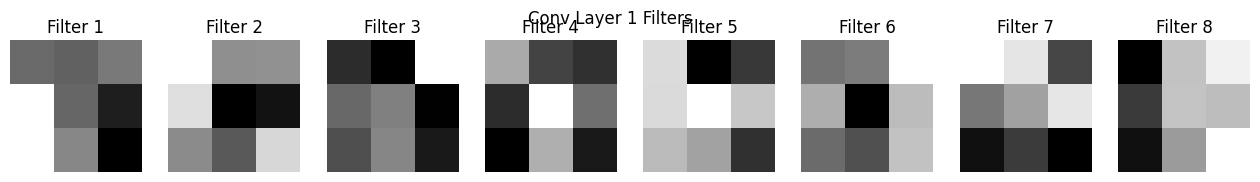

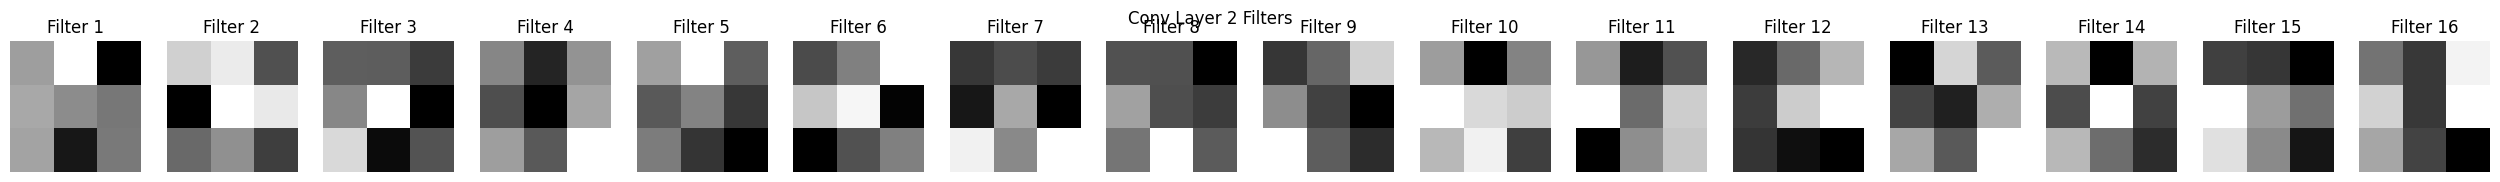

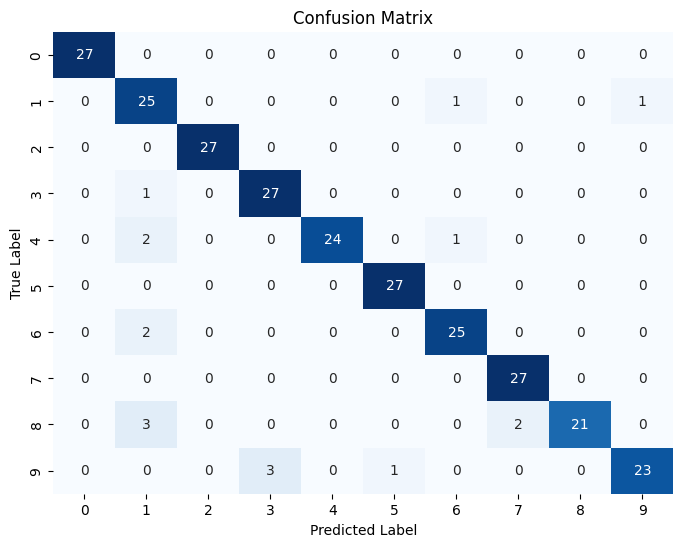

In [34]:
import matplotlib.pyplot as plt

def plot_conv_filters(conv_weights):
    """
    conv_weights: list of numpy arrays с весами свёрточных слоёв.
    Каждый элемент shape: (num_filters, in_channels, k, k)
    Отображаем каждый фильтр для каждого слоя.
    """
    for layer_idx, weights in enumerate(conv_weights):
        num_filters, in_channels, k, _ = weights.shape

        # Если входных каналов несколько, например 3, можно отобразить каждый отдельно.
        # В твоём случае in_channels=1, поэтому просто отображаем 2D фильтры.

        plt.figure(figsize=(num_filters*2, 2))
        plt.suptitle(f'Conv Layer {layer_idx + 1} Filters')

        for i in range(num_filters):
            plt.subplot(1, num_filters, i+1)
            # Отобразим только первый (и единственный) канал фильтра
            filt = weights[i, 0]
            plt.imshow(filt, cmap='gray')
            plt.axis('off')
            plt.title(f'Filter {i+1}')
        plt.show()

# Использование:
plot_conv_filters(model.conv_weights)

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Предсказания (у тебя уже есть)
# y_test_pred — предсказанные классы (индексы)
# y_test_true — истинные классы (индексы)

cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



полносвязная НС для классификации


In [19]:
import numpy as np
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch.nn.functional as F
import torch

np.random.seed(42)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(x):
    return np.maximum(0, x)

def softmax(z):
    exp = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

def activation_fun(x, act_type='relu'):
    if act_type == 'relu':
        return relu(x)
    elif act_type == 'sigmoid':
        return sigmoid(x)
    elif act_type == 'softmax':
        return softmax(x)
    else:
        raise ValueError(f"Unknown activation type: {act_type}")

def conv2d(X, W, b, stride=1, padding=0):
    """
    X: (N, C_in, H, W)
    W: (C_out, C_in, k, k)
    b: (C_out,)
    """
    N, C_in, H, W_in = X.shape
    C_out, _, k, _ = W.shape

    # Padding
    if padding > 0:
        X_padded = np.pad(
            X,
            ((0,0), (0,0), (padding,padding), (padding,padding)),
            mode='constant'
        )
    else:
        X_padded = X

    H_out = (H - k + 2 * padding) // stride + 1
    W_out = (W_in - k + 2 * padding) // stride + 1

    out = np.zeros((N, C_out, H_out, W_out))

    for n in range(N):
        for c_out in range(C_out):
            for i in range(H_out):
                for j in range(W_out):
                    h_start = i * stride
                    w_start = j * stride
                    window = X_padded[n, :, h_start:h_start+k, w_start:w_start+k]
                    out[n, c_out, i, j] = np.sum(window * W[c_out]) + b[c_out]

    return out


def max_pool(X, size=2, stride=2):
    """
    X: (N, C, H, W)
    """
    N, C, H, W = X.shape
    H_out = (H - size) // stride + 1
    W_out = (W - size) // stride + 1

    out = np.zeros((N, C, H_out, W_out))

    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    h_start = i * stride
                    w_start = j * stride
                    window = X[n, c, h_start:h_start+size, w_start:w_start+size]
                    out[n, c, i, j] = np.max(window)

    return out

def flatten(X):
    return X.reshape(X.shape[0], -1)




class NeuralNetwork:
    def __init__(self, input_size, architecture, output_size=1, classif_type='bin'):
        self.classif_type = classif_type
        layer_sizes = [input_size] + architecture + [output_size]
        self.L = len(layer_sizes) - 1

        self.weights = []
        self.biases = []
        for i in range(self.L):
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)

        # Для мониторинга
        self.train_loss = []
        self.val_loss = []
        self.test_loss = []
        self.test_acc = []
        self.train_acc = []
        self.val_acc = []
        self.y_pred_check =[]


    def forward(self, X):
        activations = [X]
        zs = []
        A = X
        for i in range(self.L):
            Z = A @ self.weights[i] + self.biases[i]
            zs.append(Z)
            if i != self.L - 1:
                A = activation_fun(Z, 'relu')
            else:
                if self.classif_type == 'bin':
                    A = activation_fun(Z, 'sigmoid')
                else:
                    A = activation_fun(Z, 'softmax')
            activations.append(A)
        return A, zs, activations


    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        if self.classif_type == 'bin':

            eps = 1e-15
            y_pred = np.clip(y_pred, eps, 1 - eps)
            loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
            print(loss,y_pred,y_true)

        else:

            eps = 1e-15
            y_pred = np.clip(y_pred, eps, 1 - eps)
            loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        return loss

    def backward(self, y_true, zs, activations):
        m = y_true.shape[0]

        grads_W = [None] * self.L
        grads_b = [None] * self.L

        A_final = activations[-1]

        if self.classif_type == 'bin':
            y_true = y_true.reshape(-1, 1)
            dZ = A_final - y_true
        else:
            dZ = A_final - y_true

        for i in reversed(range(self.L)):
            A_prev = activations[i]
            grads_W[i] = (A_prev.T @ dZ) / m
            grads_b[i] = np.sum(dZ, axis=0, keepdims=True) / m
            if i > 0:
                dA_prev = dZ @ self.weights[i].T
                Z_prev = zs[i-1]
                dZ = dA_prev * (Z_prev > 0)  # relu derivative

        return grads_W, grads_b

    def update_params(self, grads_W, grads_b, lr):
        for i in range(self.L):
            self.weights[i] -= lr * grads_W[i]
            self.biases[i]  -= lr * grads_b[i]

    def predict(self, X):
        y_pred, _, _ = self.forward(X)
        if self.classif_type == 'bin':
            return (y_pred > 0.5).astype(int).ravel()
        else:
            return np.argmax(y_pred, axis=1)

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    def fit_CNN(self,
            X_train, y_train,
            X_val=None, y_val=None,
            epochs=10,
            batch_size=32,
            lr=1e-3,
            verbose=True):
        """
        Обучение CNN
        Все метрики считаются через CNN_Forward (NumPy)
        """

        N = X_train.shape[0]
        indices = np.arange(N)

        for epoch in range(epochs):
            np.random.shuffle(indices)

            epoch_loss = 0.0

            # -------- TRAIN LOOP --------
            for start in range(0, N, batch_size):
                end = start + batch_size
                batch_idx = indices[start:end]

                X_batch = X_train[batch_idx]
                y_batch = y_train[batch_idx]

                # backward + update (torch)
                loss = self.CNN_Backward(X_batch, y_batch, lr)
                epoch_loss += loss

            epoch_loss /= (N // batch_size)

            # -------- METRICS (NumPy forward) --------
            y_train_pred, _, _ = self.CNN_Forward(X_train)
            train_acc = accuracy_score(y_train, y_train_pred, self.classif_type)

            self.train_loss.append(epoch_loss)
            self.train_acc.append(train_acc)

            if X_val is not None:
                y_val_pred, _, _ = self.CNN_Forward(X_val)
                val_acc = accuracy_score(y_val, y_val_pred, self.classif_type)

                self.val_acc.append(val_acc)

            if verbose:
                print(
                    f"Epoch [{epoch+1}/{epochs}] | "
                    f"Loss: {epoch_loss:.4f} | "
                    f"Train Acc: {train_acc:.4f}" +
                    (f" | Val Acc: {val_acc:.4f}" if X_val is not None else "")
                )





    def fit(self, X_train, y_train, X_val, y_val, X_test, y_test,
            lr=0.01, epochs=100, batch_size=32):

        m = X_train.shape[0]

        for epoch in range(1, epochs + 1):
            perm = np.random.permutation(m)
            X_shuffled = X_train[perm]
            y_shuffled = y_train[perm]

            for start in range(0, m, batch_size):
                end = min(start + batch_size, m)
                xb = X_shuffled[start:end]
                yb = y_shuffled[start:end]

                y_pred, zs, activations = self.forward(xb)
                grads_W, grads_b = self.backward(yb, zs, activations)
                self.update_params(grads_W, grads_b, lr)

            # ---------------- TRAIN METRICS ----------------
            y_train_pred_prob, _, _ = self.forward(X_train)
            train_loss = self.compute_loss(y_train, y_train_pred_prob)
            y_train_pred = self.predict(X_train)

            if self.classif_type == 'bin':
                train_acc = accuracy_score(y_train, y_train_pred)
            else:
                train_acc = accuracy_score(np.argmax(y_train, axis=1), y_train_pred)

            # ---------------- VAL METRICS ----------------
            y_val_pred_prob, _, _ = self.forward(X_val)
            val_loss = self.compute_loss(y_val, y_val_pred_prob)
            y_val_pred = self.predict(X_val)

            if self.classif_type == 'bin':
                val_acc = accuracy_score(y_val, y_val_pred)
            else:
                val_acc = accuracy_score(np.argmax(y_val, axis=1), y_val_pred)

            # ---------------- TEST METRICS ----------------
            y_test_pred_prob, _, _ = self.forward(X_test)

            self.y_pred_check.append(y_test_pred_prob)
            test_loss = self.compute_loss(y_test, y_test_pred_prob)
            y_test_pred = self.predict(X_test)

            if self.classif_type == 'bin':
                test_acc = accuracy_score(y_test, y_test_pred)
                test_precision = precision_score(y_test, y_test_pred)
                test_recall = recall_score(y_test, y_test_pred)
                test_f1 = f1_score(y_test, y_test_pred)
            else:
                y_test_true = np.argmax(y_test, axis=1)
                test_acc = accuracy_score(y_test_true, y_test_pred)
                test_precision = precision_score(y_test_true, y_test_pred, average='macro')
                test_recall = recall_score(y_test_true, y_test_pred, average='macro')
                test_f1 = f1_score(y_test_true, y_test_pred, average='macro')

            # Save history
            self.train_loss.append(train_loss)
            self.val_loss.append(val_loss)
            self.test_loss.append(test_loss)
            self.test_acc.append(test_acc)
            self.train_acc.append(train_acc)
            self.val_acc.append(val_acc)

            # Print every 10 epochs
            if epoch % 10 == 0 or epoch == 1:
                print(f"Epoch {epoch}: "
                      f"Train loss={train_loss:.4f}, Val loss={val_loss:.4f}, "
                      f"Train acc={train_acc:.4f}, Val acc={val_acc:.4f} | "
                      f"Test loss={test_loss:.4f}, Test acc={test_acc:.4f}, "
                      f"P={test_precision:.4f}, R={test_recall:.4f}, F1={test_f1:.4f}")




Загрузка данных, бинарная классификация



In [20]:
import numpy as np
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (398, 30), Val shape: (114, 30), Test shape: (57, 30)


Создание и обучение модели

In [21]:
nn_bin = NeuralNetwork(input_size=X_train.shape[1], architecture=[32, 16], output_size=1, classif_type='bin')
nn_bin.fit(X_train, y_train, X_val, y_val, X_test, y_test, lr=0.01, epochs=1000, batch_size=32)

Выходные данные были обрезаны до нескольких последних строк (5000).
 [9.97454315e-01]
 [9.99595792e-01]
 [9.97226773e-01]
 [9.99831910e-01]
 [5.66816112e-09]
 [9.87243432e-01]
 [9.93169145e-07]
 [1.12529949e-06]
 [9.97792616e-01]
 [9.99344098e-01]
 [1.45291867e-11]
 [1.70687300e-02]
 [2.04989985e-11]
 [1.00000000e-15]
 [9.75533480e-01]
 [9.87188472e-01]
 [1.41482906e-04]
 [9.61338353e-01]
 [9.99277464e-01]
 [9.99927360e-01]
 [9.97821791e-01]
 [1.07466244e-01]
 [1.05655134e-03]
 [9.99358630e-01]
 [9.99956592e-01]
 [9.98584163e-01]
 [7.44529945e-06]
 [9.93628490e-01]
 [9.95686991e-01]
 [1.00000000e-15]
 [9.98419607e-01]
 [3.74771824e-05]
 [4.85462821e-11]
 [9.98068498e-01]
 [9.98070934e-01]
 [9.96010399e-01]
 [9.93702326e-01]
 [9.98853276e-01]
 [9.97398684e-01]
 [9.99499694e-01]
 [1.00000000e-15]
 [9.99410222e-01]
 [1.99914495e-07]
 [9.79307804e-01]
 [9.93930168e-01]
 [9.95210104e-01]
 [8.76583597e-07]
 [9.85667709e-01]
 [9.97334404e-01]
 [1.80956982e-12]
 [9.98461223e-01]
 [9.98918514e-

Визуализация


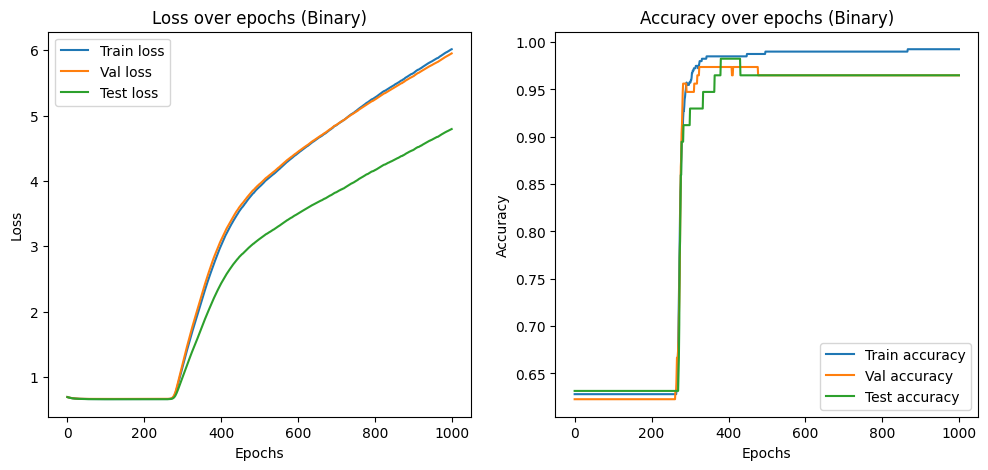

[1 0 1 0 1 1 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 0 1 1 1 0
 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 0 0]


In [22]:

# Графики
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(nn_bin.train_loss, label='Train loss')
plt.plot(nn_bin.val_loss, label='Val loss')
plt.plot(nn_bin.test_loss, label='Test loss')
plt.title("Loss over epochs (Binary)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(nn_bin.train_acc, label='Train accuracy')
plt.plot(nn_bin.val_acc, label='Val accuracy')
plt.plot(nn_bin.test_acc, label='Test accuracy')
plt.title("Accuracy over epochs (Binary)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

print(y_test)

Загрузка и подготовка данных, мультиклассовая классификация



In [5]:
data = load_iris()
X, y = data.data, data.target.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(X, y_onehot, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=np.argmax(y_temp, axis=1))

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (105, 4), Val shape: (30, 4), Test shape: (15, 4)


Инициализация и обучение модели (мультиклассовая)


In [7]:
nn_multi = NeuralNetwork(input_size=X_train.shape[1], architecture=[32, 16], output_size=3, classif_type='multi')
nn_multi.fit(X_train, y_train, X_val, y_val, X_test, y_test, lr=0.01, epochs=1000, batch_size=16)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Epoch 1: Train loss=1.0986, Val loss=1.0986, Train acc=0.3619, Val acc=0.3667 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 10: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 20: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Epoch 30: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 40: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 50: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

...

Epoch 620: Train loss=0.5754, Val loss=0.5763, Train acc=0.6762, Val acc=0.6667 | Test loss=0.5812, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 630: Train loss=0.5533, Val loss=0.5544, Train acc=0.6762, Val acc=0.6667 | Test loss=0.5589, Test acc=0.6667, P=0.5000, R=0.6667, F1=0.5556
Epoch 640: Train loss=0.5358, Val loss=0.5373, Train acc=0.6762, Val acc=0.6667 | Test loss=0.5412, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Epoch 650: Train loss=0.5216, Val loss=0.5235, Train acc=0.6762, Val acc=0.6667 | Test loss=0.5269, Test acc=0.6667, P=0.5000, R=0.6667, F1=0.5556
Epoch 660: Train loss=0.5097, Val loss=0.5121, Train acc=0.6762, Val acc=0.6667 | Test loss=0.5148, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 670: Train loss=0.4995, Val loss=0.5025, Train acc=0.6762, Val acc=0.6667 | Test loss=0.5045, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 680: Train loss=0.4905, Val loss=0.4942, Train acc=0.6762, Val acc=0.6667 | Test loss=0.4954, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 690: Train loss=0.4821, Val loss=0.4869, Train acc=0.6762, Val acc=0.7000 | Test loss=0.4872, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 700: Train loss=0.4740, Val loss=0.4800, Train acc=0.6762, Val acc=0.7000 | Test loss=0.4793, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 710: Train loss=0.4658, Val loss=0.4734, Train acc=0.6762, Val acc=0.7000 | Test loss=0.4717, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 720: Train loss=0.4575, Val loss=0.4670, Train acc=0.6857, Val acc=0.7000 | Test loss=0.4642, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 730: Train loss=0.4485, Val loss=0.4605, Train acc=0.6952, Val acc=0.7000 | Test loss=0.4562, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 740: Train loss=0.4390, Val loss=0.4538, Train acc=0.7238, Val acc=0.7000 | Test loss=0.4480, Test acc=0.7333, P

Визуализация процесса обучения


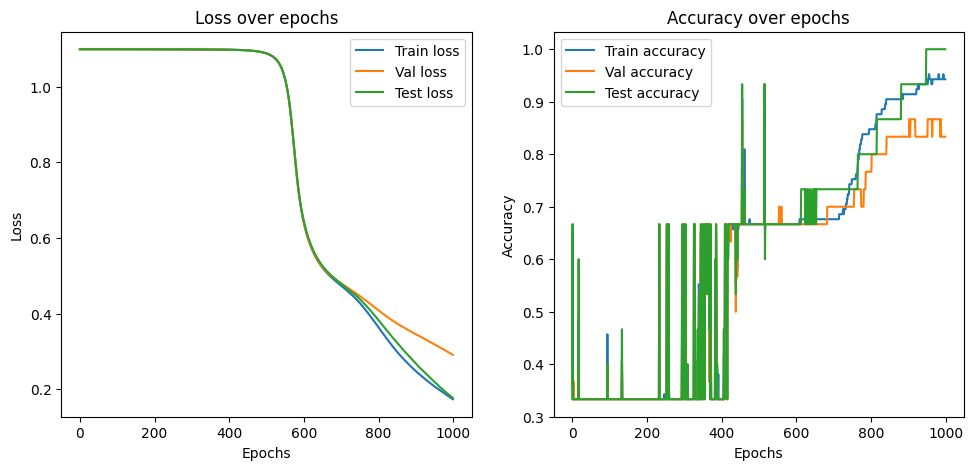

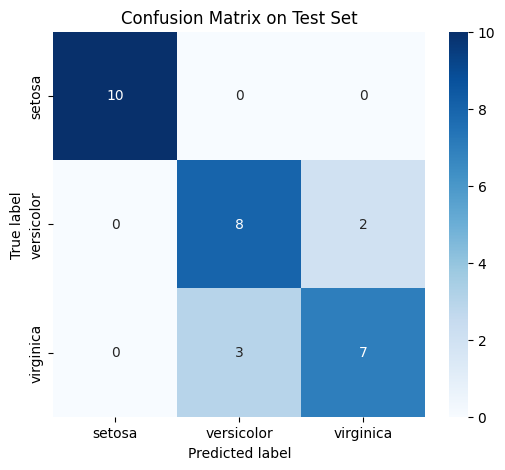

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(nn_multi.train_loss, label='Train loss')
plt.plot(nn_multi.val_loss, label='Val loss')
plt.plot(nn_multi.test_loss, label='Test loss')
plt.title("Loss over epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(nn_multi.train_acc, label='Train accuracy')
plt.plot(nn_multi.val_acc, label='Val accuracy')
plt.plot(nn_multi.test_acc, label='Test accuracy')
plt.title("Accuracy over epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

y_val_pred = nn_multi.predict(X_val)
y_val_true = np.argmax(y_val, axis=1)

# Матрица ошибок
cm = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix on Test Set')
plt.show()

plt.show()

Многоклассовая(данные)


NumPy conv output shape: (8, 8, 8)
Torch conv output shape: (8, 8, 8)
Mean abs diff (conv outputs): 1.5598061509081163e-08
Epoch 1: train_loss=2.3154, val_loss=2.0516, train_acc=0.2237, val_acc=0.3750
Epoch 5: train_loss=0.5870, val_loss=0.4574, train_acc=0.8877, val_acc=0.9236
Epoch 10: train_loss=0.1881, val_loss=0.1620, train_acc=0.9547, val_acc=0.9653
Epoch 15: train_loss=0.0970, val_loss=0.1024, train_acc=0.9835, val_acc=0.9826
Epoch 20: train_loss=0.0559, val_loss=0.0745, train_acc=0.9913, val_acc=0.9826
Test accuracy: 0.9583 (345/360)


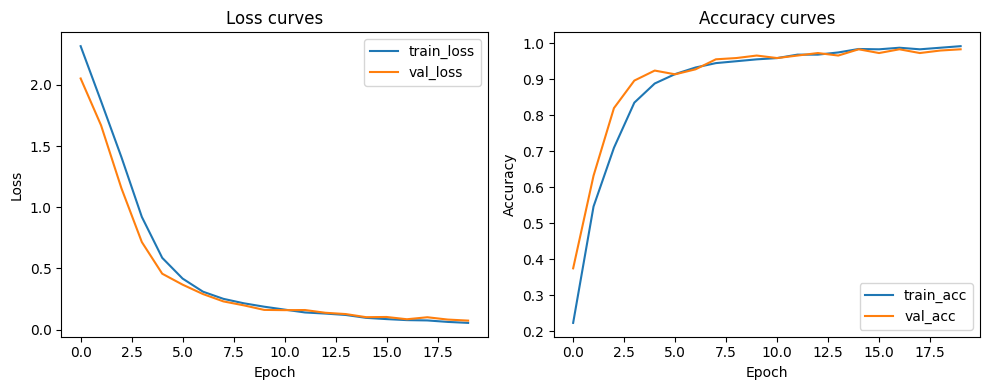

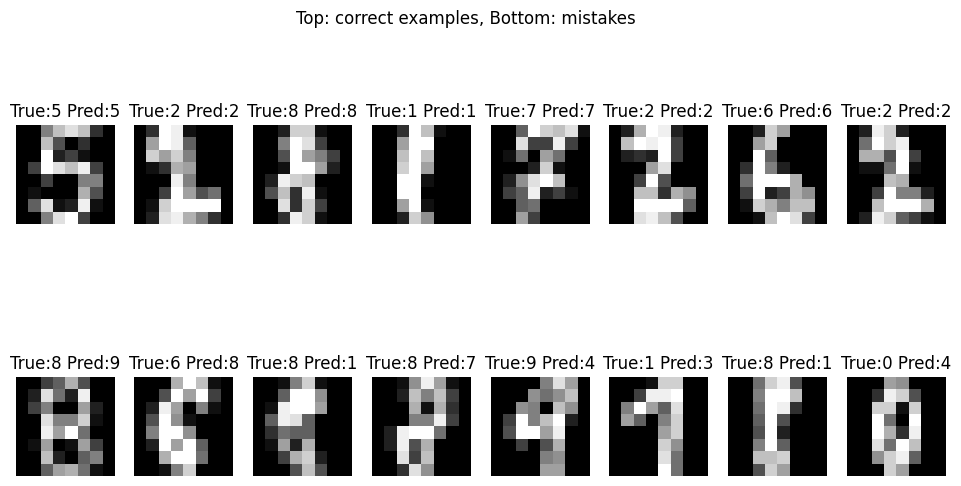

Confusion matrix (rows=true, cols=pred):
 [[35  0  0  0  1  0  0  0  0  0]
 [ 0 33  0  2  0  1  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 35  0  1  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  1 30  1]
 [ 0  0  0  2  2  0  0  0  0 32]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.92      0.92        36
           2       1.00      1.00      1.00        35
           3       0.90      1.00      0.95        37
           4       0.92      0.97      0.95        36
           5       0.97      1.00      0.99        37
           6       0.97      0.97      0.97        36
           7       0.97      1.00      0.99        36
           8       0.97      0.86      0.91        35
           9       0.97      0.89      0.93        36

    ac

In [9]:
# full_cnn_numpy_pytorch.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# ------------------ NumPy implementations ------------------

def conv2d_single_channel(input, kernel, stride=1, padding=0):
    """
    input: (H, W)
    kernel: (kH, kW)
    returns: (outH, outW)
    """
    if padding > 0:
        input_padded = np.pad(input, ((padding, padding), (padding, padding)), mode='constant')
    else:
        input_padded = input
    H, W = input_padded.shape
    kH, kW = kernel.shape
    outH = (H - kH) // stride + 1
    outW = (W - kW) // stride + 1
    out = np.zeros((outH, outW))
    for i in range(outH):
        for j in range(outW):
            region = input_padded[i*stride:i*stride+kH, j*stride:j*stride+kW]
            out[i, j] = np.sum(region * kernel)
    return out

def conv2d_multi_channel(input, kernels, biases=None, stride=1, padding=0):
    """
    input: (C_in, H, W)
    kernels: (C_out, C_in, kH, kW)
    biases: (C_out,) or None
    returns: (C_out, outH, outW)
    """
    C_in, H, W = input.shape
    C_out, _, kH, kW = kernels.shape
    if padding > 0:
        input_padded = np.pad(input, ((0,0),(padding,padding),(padding,padding)), mode='constant')
    else:
        input_padded = input
    outH = (H + 2*padding - kH) // stride + 1
    outW = (W + 2*padding - kW) // stride + 1
    out = np.zeros((C_out, outH, outW))
    for o in range(C_out):
        acc = np.zeros((outH, outW))
        for c in range(C_in):
            acc += conv2d_single_channel(input_padded[c], kernels[o, c], stride=stride, padding=0)
        if biases is not None:
            acc += biases[o]
        out[o] = acc
    return out

def relu_np(x):
    return np.maximum(0, x)

def maxpool2d_np(input, pool=2, stride=2):
    """
    input: (C, H, W)
    returns: (C, outH, outW)
    """
    C, H, W = input.shape
    outH = (H - pool) // stride + 1
    outW = (W - pool) // stride + 1
    out = np.zeros((C, outH, outW))
    for c in range(C):
        for i in range(outH):
            for j in range(outW):
                region = input[c, i*stride:i*stride+pool, j*stride:j*stride+pool]
                out[c, i, j] = np.max(region)
    return out

def flatten_np(x):

    return x.reshape(-1)

# Helper: compare numpy conv with torch conv (same weights)
def compare_numpy_torch_conv(input_np, kernels_np, biases_np, stride=1, padding=0):
    out_np = conv2d_multi_channel(input_np, kernels_np, biases_np, stride=stride, padding=padding)
    input_t = torch.tensor(input_np[np.newaxis,:,:,:], dtype=torch.float32)  # (1, C, H, W)
    conv = nn.Conv2d(in_channels=input_np.shape[0], out_channels=kernels_np.shape[0],
                     kernel_size=(kernels_np.shape[2], kernels_np.shape[3]), stride=stride, padding=padding, bias=(biases_np is not None))
    with torch.no_grad():
        conv.weight.copy_(torch.tensor(kernels_np, dtype=torch.float32))
        if biases_np is not None:
            conv.bias.copy_(torch.tensor(biases_np, dtype=torch.float32))
    out_t = conv(input_t).detach().numpy()[0]
    return out_np, out_t

# ------------------ Dataset (sklearn digits) ------------------
digits = load_digits()
X = digits.images  # (n_samples, 8, 8)
y = digits.target  # 0-9
X = X / 16.0      # normalize
X = X[:, np.newaxis, :, :]  # (N,1,8,8)

# Train/val/test split
from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval)

# Convert to torch tensors
tensor_X_train = torch.tensor(X_train, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train, dtype=torch.long)
tensor_X_val = torch.tensor(X_val, dtype=torch.float32)
tensor_y_val = torch.tensor(y_val, dtype=torch.long)
tensor_X_test = torch.tensor(X_test, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(tensor_X_train, tensor_y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(tensor_X_val, tensor_y_val), batch_size=64)
test_loader = DataLoader(TensorDataset(tensor_X_test, tensor_y_test), batch_size=64)

# ------------------ PyTorch CNN (for autograd/backprop) ------------------
class SmallCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 8, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16*2*2, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cpu")
model = SmallCNN(in_channels=1, num_classes=10).to(device)

# initialize
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)
model.apply(init_weights)

# Quick numerical check: compare numpy conv1 with torch conv1 for first test example
with torch.no_grad():
    w_conv1 = model.conv1.weight.detach().numpy()  # (8,1,3,3)
    b_conv1 = model.conv1.bias.detach().numpy()
example_np_input = X_test[0]  # (1,8,8)
out_np, out_t = compare_numpy_torch_conv(example_np_input, w_conv1, b_conv1, stride=1, padding=1)
print("NumPy conv output shape:", out_np.shape)
print("Torch conv output shape:", out_t.shape)
print("Mean abs diff (conv outputs):", np.abs(out_np - out_t).mean())

# ------------------ Training (autograd via PyTorch) ------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_corr = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_corr += (preds == yb).sum().item()
            val_total += xb.size(0)
    val_loss = val_loss / val_total
    val_acc = val_corr / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

# ------------------ Test evaluation ------------------
model.eval()
test_corr = 0
test_total = 0
all_preds = []
all_targets = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())
        test_corr += (preds == yb).sum().item()
        test_total += xb.size(0)
test_acc = test_corr / test_total
print(f"Test accuracy: {test_acc:.4f} ({test_corr}/{test_total})")

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# ------------------ Plot training curves ------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curves")

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy curves")

plt.tight_layout()
plt.show()

# ------------------ Visualize examples ------------------
correct_idx = np.where(all_preds == all_targets)[0]
incorrect_idx = np.where(all_preds != all_targets)[0]

num_show = 8
plt.figure(figsize=(12,6))
for i in range(num_show):
    if i < len(correct_idx):
        idx = correct_idx[i]
        img = X_test[idx,0]
        pred = all_preds[idx]
        true = all_targets[idx]
        plt.subplot(2, num_show, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"True:{true} Pred:{pred}")
        plt.axis('off')

for i in range(num_show):
    if i < len(incorrect_idx):
        idx = incorrect_idx[i]
        img = X_test[idx,0]
        pred = all_preds[idx]
        true = all_targets[idx]
        plt.subplot(2, num_show, num_show + i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"True:{true} Pred:{pred}")
        plt.axis('off')

plt.suptitle("Top: correct examples, Bottom: mistakes")
plt.show()

# Confusion matrix + report
cm = confusion_matrix(all_targets, all_preds)
print("Confusion matrix (rows=true, cols=pred):\n", cm)
print("\nClassification report:\n", classification_report(all_targets, all_preds))

# ------------------ Demonstrate NumPy forward pipeline (conv->relu->pool->conv->relu->pool->flatten)
with torch.no_grad():
    w1 = model.conv1.weight.detach().numpy()  # (8,1,3,3)
    b1 = model.conv1.bias.detach().numpy()
    w2 = model.conv2.weight.detach().numpy()  # (16,8,3,3)
    b2 = model.conv2.bias.detach().numpy()

# take a test image (single)
img = X_test[5]  # (1,8,8)
out1 = conv2d_multi_channel(img, w1, b1, stride=1, padding=1)  # (8,8,8)
out1_r = relu_np(out1)
out1_p = maxpool2d_np(out1_r, pool=2, stride=2)  # (8,4,4)
out2 = conv2d_multi_channel(out1_p, w2, b2, stride=1, padding=1)  # (16,4,4)
out2_r = relu_np(out2)
out2_p = maxpool2d_np(out2_r, pool=2, stride=2)  # (16,2,2)
flat_np = out2_p.reshape(-1)

# torch pipeline for the same image
img_t = torch.tensor(img[np.newaxis,:,:,:], dtype=torch.float32)
with torch.no_grad():
    t1 = model.pool1(model.relu1(model.conv1(img_t))).numpy()[0]  # (8,4,4)
    t2 = model.pool2(model.relu2(model.conv2(torch.tensor(t1[np.newaxis,:,:,:], dtype=torch.float32)))).numpy()[0]  # (16,2,2)
    flat_t = t2.reshape(-1)

print("Numpy flat len:", flat_np.shape[0], "Torch flat len:", flat_t.shape[0])
print("Mean abs diff between NumPy features and Torch features:", np.abs(flat_np - flat_t).mean())

# Save model
torch.save(model.state_dict(), "small_cnn_digits.pth")
print("Saved model to small_cnn_digits.pth (in current working directory).")


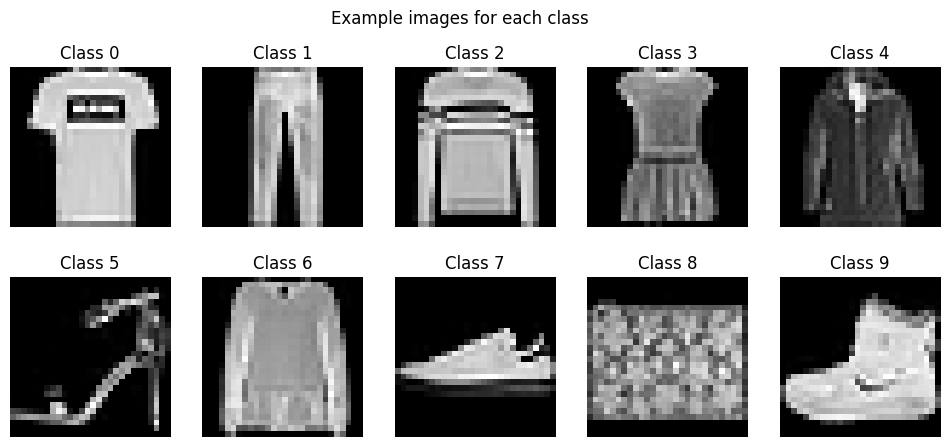

Training Fully Connected Network...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1: Train loss=2.3016, Val loss=2.3016, Train acc=0.2303, Val acc=0.2329 | Test loss=2.3016, Test acc=0.2272, P=0.1935, R=0.2272, F1=0.1354


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Epoch 10: Train loss=0.9796, Val loss=0.9737, Train acc=0.6526, Val acc=0.6542 | Test loss=1.0042, Test acc=0.6494, P=0.6774, R=0.6494, F1=0.6007
Epoch 20: Train loss=0.6655, Val loss=0.6539, Train acc=0.7484, Val acc=0.7531 | Test loss=0.6951, Test acc=0.7314, P=0.7972, R=0.7314, F1=0.7362
Epoch 30: Train loss=0.5298, Val loss=0.5191, Train acc=0.8170, Val acc=0.8167 | Test loss=0.5585, Test acc=0.8046, P=0.8006, R=0.8046, F1=0.8008
Training CNN...
Epoch 1: Train loss=2.1581, Val loss=2.1595, Train acc=0.2409, Val acc=0.2353 | Test loss=2.1589, Test acc=0.2352, P=0.1540, R=0.2352, F1=0.1658


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report
from tensorflow.keras.datasets import fashion_mnist

# Твои классы NeuralNetwork и NeuralNetwork_CNN должны быть уже определены, а также вспомогательные функции:
# sigmoid, relu, softmax, conv2d, max_pool, flatten
# backward для CNN с PyTorch — предполагается, что torch и F импортированы

# --- 1. Загрузка и подготовка данных ---
(X_train_val, y_train_val), (X_test, y_test) = fashion_mnist.load_data()

# Пример изображений для разных классов
fig, axs = plt.subplots(2, 5, figsize=(12,5))
for i in range(10):
    idx = np.where(y_train_val == i)[0][0]
    axs[i//5, i%5].imshow(X_train_val[idx], cmap='gray')
    axs[i//5, i%5].set_title(f'Class {i}')
    axs[i//5, i%5].axis('off')
plt.suptitle("Example images for each class")
plt.show()

# Нормализация [0,1]
X_train_val = X_train_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Добавляем размерность канала (C=1) для CNN
X_train_val_cnn = X_train_val[:, np.newaxis, :, :]
X_test_cnn = X_test[:, np.newaxis, :, :]

# One-hot кодирование меток
encoder = OneHotEncoder(sparse_output=False)
y_train_val_onehot = encoder.fit_transform(y_train_val.reshape(-1,1))
y_test_onehot = encoder.transform(y_test.reshape(-1,1))

# Разбиваем train_val на train и val (например 85% train, 15% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val_onehot, test_size=0.15, random_state=42, stratify=y_train_val)

X_train_cnn, X_val_cnn = train_test_split(
    X_train_val_cnn, test_size=0.15, random_state=42, stratify=y_train_val)

# Для полносвязной сети сделаем flatten
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# --- 2. Обучение полносвязной сети ---
input_size = X_train_flat.shape[1]
fc_arch = [128, 64]

model_fc = NeuralNetwork(input_size=input_size, architecture=fc_arch, output_size=10, classif_type='multi')

print("Training Fully Connected Network...")
model_fc.fit(X_train_flat, y_train, X_val_flat, y_val, X_test_flat, y_test_onehot,
             lr=0.01, epochs=30, batch_size=128)

# --- 3. Обучение сверточной сети ---
conv_arch = [
    {'filters': 1, 'kernel_size': 3, 'stride':1, 'padding':1, 'pool': True},
    {'filters': 1, 'kernel_size': 3, 'stride':1, 'padding':1, 'pool': True}
]

fc_arch_cnn = [64]

model_cnn = NeuralNetwork_CNN(
    input_shape=(1, 28, 28),
    conv_arch=conv_arch,
    fc_arch=fc_arch_cnn,
    output_size=10,
    classif_type='multi'
)

print("Training CNN...")
model_cnn.fit(
    X_train_cnn, y_train,
    X_val_cnn, y_val,
    X_test_cnn, y_test_onehot,
    lr=0.01,
    epochs=30,
    batch_size=128
)

# --- 4. Сравнение результатов ---

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(model_fc.train_loss, label='FC Train Loss')
plt.plot(model_fc.val_loss, label='FC Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('FC Network Loss')

plt.subplot(1,2,2)
plt.plot(model_cnn.train_loss, label='CNN Train Loss')
plt.plot(model_cnn.val_loss, label='CNN Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Loss')

plt.show()

print("FC Network Test Classification Report:")
y_test_pred_fc = model_fc.predict(X_test_flat)
y_test_true = np.argmax(y_test_onehot, axis=1)
print(classification_report(y_test_true, y_test_pred_fc))

print("CNN Test Classification Report:")
y_test_pred_cnn = model_cnn.predict(X_test_cnn)
print(classification_report(y_test_true, y_test_pred_cnn))


In [18]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.images  # (n_samples, 8, 8)
y = digits.target  # 0-9
X = X / 16.0      # normalize
X = X[:, np.newaxis, :, :]  # (N,1,8,8)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = NeuralNetwork(
    input_shape=(8, 8, 1),
    conv_architecture=[
        (8, 3, 1, 0)   # 1 conv layer
    ],
    fc_architecture=[32],
    output_size=10,
    classif_type='multi',
    device='cpu'
)

model.fit_CNN(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    lr=1e-3
)

model.plot_training()
model.evaluate(X_test, y_test)
model.visualize_predictions(X_test, y_test)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x72 and 288x32)

Многоклассовая(Инициализация)

In [ ]:
nn2 = NeuralNetwork(input_size=4, architecture=[16, 16], output_size=3)
nn2.fit(X_train, y_train, X_val, y_val, lr=0.01, epochs=300, batch_size=16)


Визуализация

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.1175 - val_loss: 0.0658
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0626 - val_loss: 0.0549
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0538 - val_loss: 0.0502
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0493 - val_loss: 0.0474
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0461 - val_loss: 0.0450
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0438 - val_loss: 0.0433
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0423 - val_loss: 0.0423
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0412 - val_loss: 0.0413
Epoch 9/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0402 - val_loss: 0.0401
Epoch 10/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0392 - val_loss: 0.0394
Epoch 11/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0382 - val_loss: 0.0388
Epoch 12/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 

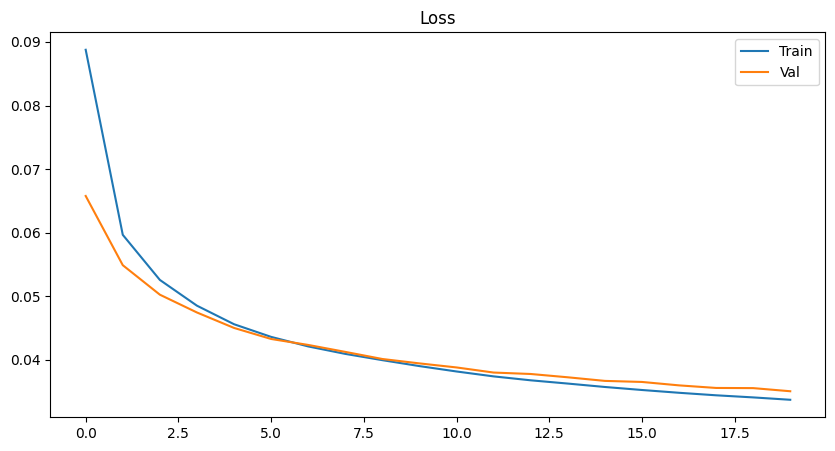

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


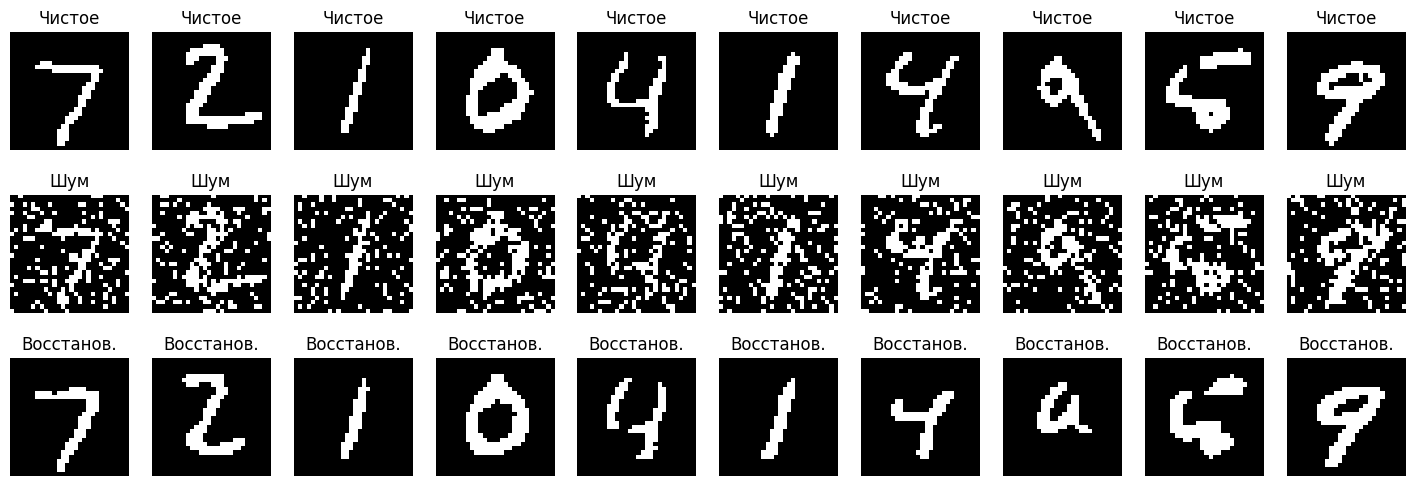

MSE(зашумлённые vs чистые):      0.15901951
MSE(восстановленные vs чистые): 0.047835078


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------------
# 1. Загрузка и подготовка данных
# -------------------------------------------------------

(x_train, _), (x_test, _) = mnist.load_data()

# Нормализация
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Бинаризация исходных изображений
x_train = (x_train >= 0.5).astype("float32")
x_test = (x_test >= 0.5).astype("float32")

# Развёртывание
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -------------------------------------------------------
# 2. Добавление шума + бинаризация после шума
# -------------------------------------------------------

noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(0.0, 1.0, x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0.0, 1.0, x_test.shape)

# Обрезка в диапазон [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# ⚠️ БИНАРИЗАЦИЯ ПОСЛЕ ШУМА
x_train_noisy = (x_train_noisy >= 0.5).astype("float32")
x_test_noisy = (x_test_noisy >= 0.5).astype("float32")

# -------------------------------------------------------
# 3. Построение автоэнкодера
# -------------------------------------------------------

input_img = Input(shape=(784,))

encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)

# Сигмоида, но выход потом тоже бинаризуем
decoded = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss='mse')

# -------------------------------------------------------
# 4. Обучение
# -------------------------------------------------------

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2
)

# -------------------------------------------------------
# 5. График функции потерь
# -------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Val'])
plt.title("Loss")
plt.show()

# -------------------------------------------------------
# 6. Восстановление изображений
# -------------------------------------------------------

decoded_imgs = autoencoder.predict(x_test_noisy)

# Бинаризация выхода для отсутствия серых пикселей
decoded_imgs_bin = (decoded_imgs >= 0.5).astype("float32")

# -------------------------------------------------------
# 7. Визуализация — только чёрно-белые пиксели
# -------------------------------------------------------

n = 10
plt.figure(figsize=(18, 6))

for i in range(n):
    # Чистое
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    plt.axis("off")
    plt.title("Чистое")

    # Зашумлённое и бинаризованное
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    plt.axis("off")
    plt.title("Шум")

    # Восстановленное и бинаризованное
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs_bin[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    plt.axis("off")
    plt.title("Восстанов.")

plt.show()

# -------------------------------------------------------
# 8. MSE сравнение
# -------------------------------------------------------

mse_noisy = np.mean((x_test - x_test_noisy) ** 2)
mse_denoised = np.mean((x_test - decoded_imgs_bin) ** 2)

print("MSE(зашумлённые vs чистые):     ", mse_noisy)
print("MSE(восстановленные vs чистые):", mse_denoised)


фывфы

In [1]:
"""
autoencoder_dim2_visualization.py

Запуск: python autoencoder_dim2_visualization.py

Требования:
- Python 3.8+
- tensorflow (2.x)
- numpy, matplotlib

Скрипт обучает автоэнкодер с латентом 2 на MNIST и Fashion-MNIST.
"""
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

# Рандом сид для воспроизводимости (в разной степени)
np.random.seed(42)
tf.random.set_seed(42)

# Параметры
epochs = 50
batch_size = 256
latent_dim = 2
validation_split = 0.2
plot_dir = "ae_plots_dim2"
os.makedirs(plot_dir, exist_ok=True)

def build_dense_autoencoder(input_dim, latent_dim):
    """
    Строит автоэнкодер по спецификации:
    Input(input_dim) -> Dense(256,relu) -> Dense(128,relu) -> Dense(64,relu)
                     -> Dense(2, linear)  <-- latent
                     -> Dense(64,relu) -> Dense(128,relu) -> Dense(256,relu)
                     -> Dense(input_dim, sigmoid)
    Возвращает (autoencoder, encoder, decoder)
    """
    # Encoder
    input_img = Input(shape=(input_dim,), name="ae_input")
    x = Dense(256, activation='relu')(input_img)
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    latent = Dense(latent_dim, activation='linear', name="latent")(x)

    # Decoder
    d = Dense(64, activation='relu')(latent)
    d = Dense(128, activation='relu')(d)
    d = Dense(256, activation='relu')(d)
    out = Dense(input_dim, activation='sigmoid', name="reconstruction")(d)

    autoencoder = Model(inputs=input_img, outputs=out, name="autoencoder")
    encoder = Model(inputs=input_img, outputs=latent, name="encoder")

    # Построим декодер как отдельную модель: латент -> реконструкция
    latent_input = Input(shape=(latent_dim,), name="z_input")
    _d = autoencoder.get_layer(index=-4)(latent_input)  # Dense(64)
    _d = autoencoder.get_layer(index=-3)(_d)  # Dense(128)
    _d = autoencoder.get_layer(index=-2)(_d)  # Dense(256)
    _out = autoencoder.get_layer(index=-1)(_d)  # Dense(input_dim, sigmoid)
    decoder = Model(inputs=latent_input, outputs=_out, name="decoder")

    return autoencoder, encoder, decoder

def prepare_data(dataset_name):
    """
    Возвращает x_train, x_test, y_train, y_test (пиксели приведены в [0,1], развернуты 784)
    dataset_name: 'mnist' или 'fashion'
    """
    if dataset_name == 'mnist':
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
    elif dataset_name == 'fashion':
        (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
    else:
        raise ValueError("dataset_name должен быть 'mnist' или 'fashion'")

    # Нормализация в [0,1]
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # Развёртываем в 1D-векторы
    x_train = x_train.reshape((len(x_train), -1))
    x_test = x_test.reshape((len(x_test), -1))

    return x_train, x_test, y_train, y_test

def plot_loss(history, title_prefix, outpath):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f"{title_prefix} — Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(outpath)
    plt.close()

def plot_latent_scatter(z, labels, title, outpath, cmap='tab10'):
    """
    z: (N,2) латентные векторы
    labels: целые метки
    """
    plt.figure(figsize=(6,6))
    sc = plt.scatter(z[:,0], z[:,1], c=labels, cmap=cmap, s=4, alpha=0.7)
    plt.colorbar(sc, ticks=np.unique(labels))
    plt.title(title)
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.grid(True, linewidth=0.3, alpha=0.5)
    plt.tight_layout()
    plt.savefig(outpath)
    plt.close()

def plot_decoded_grid(decoder, x_latent_min, x_latent_max, y_latent_min, y_latent_max, grid_n, outpath):
    """
    Создаёт grid_n x grid_n точек в латент-пространстве, декодирует и рисует как сетку изображений.
    """
    grid_x = np.linspace(x_latent_min, x_latent_max, grid_n)
    grid_y = np.linspace(y_latent_min, y_latent_max, grid_n)[::-1]  # сверху вниз
    figure = np.zeros((28 * grid_n, 28 * grid_n))
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample)
            digit = x_decoded.reshape(28,28)
            # масштабируем на место в большой сетке
            top = i * 28
            left = j * 28
            figure[top: top + 28, left: left + 28] = digit

    plt.figure(figsize=(8,8))
    plt.imshow(figure, cmap='gray', vmin=0, vmax=1)
    plt.title("Decoded grid (latent -> image)")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(outpath)
    plt.close()

def evaluate_and_visualize(dataset_name):
    print("\n" + "="*60)
    print(f"Dataset: {dataset_name}")
    x_train, x_test, y_train, y_test = prepare_data(dataset_name)
    input_dim = x_train.shape[1]

    autoencoder, encoder, decoder = build_dense_autoencoder(input_dim, latent_dim)
    autoencoder.compile(optimizer=Adam(), loss='mse')
    autoencoder.summary()

    # Обучение
    history = autoencoder.fit(
        x_train, x_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        verbose=2
    )

    prefix = f"{dataset_name}"
    # plot loss
    plot_loss(history, f"{dataset_name.upper()}", os.path.join(plot_dir, f"{prefix}_loss.png"))
    print(f"Loss plot saved to {os.path.join(plot_dir, f'{prefix}_loss.png')}")

    # Получаем латент для теста
    z_test = encoder.predict(x_test)
    print(f"Latent shape (test): {z_test.shape}")

    # Scatter plot латент-пространства
    plot_latent_scatter(z_test, y_test, f"{dataset_name.upper()} latent (2D)", os.path.join(plot_dir, f"{prefix}_latent_scatter.png"))
    print(f"Latent scatter saved to {os.path.join(plot_dir, f'{prefix}_latent_scatter.png')}")

    # MSE на тесте (реконструкция)
    x_test_pred = autoencoder.predict(x_test)
    mse_test = np.mean((x_test - x_test_pred) ** 2)
    print(f"MSE reconstruction on test: {mse_test:.6f}")

    # Генерация сетки в латенте: выберем диапазон покрывающий точки z_test с запасом
    margin = 0.5
    x_min, x_max = z_test[:,0].min()-margin, z_test[:,0].max()+margin
    y_min, y_max = z_test[:,1].min()-margin, z_test[:,1].max()+margin

    # Показать декодированную сетку (например 15x15)
    grid_n = 15
    plot_decoded_grid(decoder, x_min, x_max, y_min, y_max, grid_n, os.path.join(plot_dir, f"{prefix}_decoded_grid.png"))
    print(f"Decoded grid saved to {os.path.join(plot_dir, f'{prefix}_decoded_grid.png')}")

    # Также сохраним несколько примеров: исходное, реконструкция, latent coords
    n_show = 10
    idx = np.random.choice(len(x_test), n_show, replace=False)
    plt.figure(figsize=(12,4))
    for i, ii in enumerate(idx):
        # оригинал
        ax = plt.subplot(3, n_show, i+1)
        plt.imshow(x_test[ii].reshape(28,28), cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
        if i==0: plt.title("Original")

        # реконструкция
        ax = plt.subplot(3, n_show, i+1+n_show)
        plt.imshow(x_test_pred[ii].reshape(28,28), cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
        if i==0: plt.title("Reconstructed")

        # точка в латенте
        ax = plt.subplot(3, n_show, i+1+2*n_show)
        zpt = z_test[ii]
        plt.scatter([zpt[0]], [zpt[1]], c=[y_test[ii]], cmap='tab10', s=40)
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.gca().invert_yaxis()
        plt.axis('off')
        if i==0: plt.title("Latent point")
    plt.suptitle(f"{dataset_name.upper()} examples and latents")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.savefig(os.path.join(plot_dir, f"{prefix}_examples.png"))
    plt.close()
    print(f"Example reconstructions saved to {os.path.join(plot_dir, f'{prefix}_examples.png')}")

    # Выводим кратко информацию
    return {
        "dataset": dataset_name,
        "mse_test": mse_test,
        "latent_test": z_test
    }

if __name__ == "__main__":
    results = []
    for ds in ['mnist', 'fashion']:
        res = evaluate_and_visualize(ds)
        results.append(res)
    print("\nSummary:")
    for r in results:
        print(f"- {r['dataset']}: MSE(test) = {r['mse_test']:.6f}")
    print(f"\nAll plots saved to directory: {plot_dir}")
    print("Готово.")



Dataset: mnist
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,266 (1.85 MB)

 Trainable params: 485,266 (1.85 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,266 (1.85 MB)

 Trainable params: 485,266 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
188/188 - 8s - 44ms/step - loss: 0.0606 - val_loss: 0.0378
Epoch 2/50
188/188 - 5s - 25ms/step - loss: 0.0343 - val_loss: 0.0321
Epoch 3/50
188/188 - 6s - 35ms/step - loss: 0.0308 - val_loss: 0.0304
Epoch 4/50
188/188 - 5s - 25ms/step - loss: 0.0296 - val_loss: 0.0294
Epoch 5/50
188/188 - 6s - 33ms/step - loss: 0.0289 - val_loss: 0.0289
Epoch 6/50
188/188 - 5s - 25ms/step - loss: 0.0285 - val_loss: 0.0285
Epoch 7/50
188/188 - 5s - 25ms/step - loss: 0.0280 - val_loss: 0.0283
Epoch 8/50
188/188 - 6s - 34ms/step - loss: 0.0277 - val_loss: 0.0279
Epoch 9/50
188/188 - 5s - 26ms/step - loss: 0.0275 - val_loss: 0.0278
Epoch 10/50
188/188 - 6s - 32ms/step - loss: 0.0272 - val_loss: 0.0276
Epoch 11/50
188/188 - 5s - 25ms/step - loss: 0.0270 - val_loss: 0.0276
Epoch 12/50
188/188 - 5s - 27ms/step - loss: 0.0268 - val_loss: 0.0271
Epoch 13/50
188/188 - 6s - 32ms/step - loss: 0.0268 - val_loss: 0.0270
Epoch 14/50
188/188 - 10s - 54ms/step - loss: 0.0266 - val_loss: 0.0268
Epoch 15/50
18

In [2]:
"""
autoencoder_vs_pca_dim32.py
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# reproducibility
np.random.seed(42)

latent_dim = 32
epochs = 40
batch_size = 256


def load_data(dataset="mnist"):
    """Загрузка и нормализация данных"""
    if dataset == "mnist":
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
    else:
        (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    x_train = x_train.reshape((len(x_train), -1))  # 784
    x_test = x_test.reshape((len(x_test), -1))

    return x_train, x_test, y_train, y_test


def build_linear_autoencoder(input_dim=784, latent_dim=32):
    """Линейный автоэнкодер: без ReLU, только 'linear'"""

    inp = Input(shape=(input_dim,))
    lat = Dense(latent_dim, activation='linear')(inp)
    out = Dense(input_dim, activation='linear')(lat)

    autoencoder = Model(inp, out, name="linear_autoencoder")
    encoder = Model(inp, lat, name="encoder")

    # decoder
    lat_inp = Input(shape=(latent_dim,))
    decoded = autoencoder.layers[-1](lat_inp)
    decoder = Model(lat_inp, decoded, name="decoder")

    autoencoder.compile(optimizer=Adam(), loss='mse')

    return autoencoder, encoder, decoder


def run_experiment(dataset_name):
    print("\n===========================")
    print(f"DATASET: {dataset_name}")
    print("===========================\n")

    # ---- LOAD DATA ----
    x_train, x_test, y_train, y_test = load_data(dataset_name)
    input_dim = x_train.shape[1]

    # ---- PCA ----
    print("Running PCA...")
    pca = PCA(n_components=latent_dim)
    pca.fit(x_train)

    x_test_pca_lat = pca.transform(x_test)
    x_test_pca_rec = pca.inverse_transform(x_test_pca_lat)
    mse_pca = np.mean((x_test - x_test_pca_rec) ** 2)
    print(f"PCA MSE reconstruction: {mse_pca:.6f}")

    # ---- Autoencoder ----
    print("Training Autoencoder...")
    autoencoder, encoder, decoder = build_linear_autoencoder(input_dim, latent_dim)
    history = autoencoder.fit(
        x_train, x_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=2
    )

    # Reconstruction
    x_test_ae_rec = autoencoder.predict(x_test)
    mse_ae = np.mean((x_test - x_test_ae_rec) ** 2)
    print(f"Autoencoder MSE reconstruction: {mse_ae:.6f}")

    # ---- Compare latent spaces ----
    print("\nComparing latent representations (cosine similarity)...")

    # PCA latent shape: (N,32)
    # AE latent shape:  (N,32)
    x_test_ae_lat = encoder.predict(x_test)

    # Compute cosine similarity matrix between latent components
    # Compare PCA vector_i and AE vector_i for each sample
    sims = []
    for i in range(5000):  # ограничим для скорости
        sims.append(
            cosine_similarity(
                x_test_pca_lat[i:i+1],
                x_test_ae_lat[i:i+1]
            )[0, 0]
        )
    sims = np.array(sims)

    print(f"Average cosine similarity (first 5000 samples): {sims.mean():.6f}")
    print(f"Std: {sims.std():.6f}")
    print(f"Min/Max: {sims.min():.6f} / {sims.max():.6f}")

    # ---- Plot training loss ----
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['loss'], label="train")
    plt.plot(history.history['val_loss'], label="val")
    plt.title(f"{dataset_name.upper()} – Linear Autoencoder Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{dataset_name}_linear_ae_loss.png")
    plt.close()

    print(f"Saved: {dataset_name}_linear_ae_loss.png")

    return {
        "dataset": dataset_name,
        "mse_pca": mse_pca,
        "mse_autoencoder": mse_ae,
        "cosine_mean": sims.mean()
    }


if __name__ == "__main__":
    results = []
    for ds in ["mnist", "fashion"]:
        results.append(run_experiment(ds))

    print("\n=== SUMMARY ===")
    for r in results:
        print(f"{r['dataset']}: PCA MSE={r['mse_pca']:.6f}, AE MSE={r['mse_autoencoder']:.6f}, Cosine={r['cosine_mean']:.6f}")



DATASET: mnist

Running PCA...
PCA MSE reconstruction: 0.016828
Training Autoencoder...
Epoch 1/40
188/188 - 3s - 16ms/step - loss: 0.0495 - val_loss: 0.0296
Epoch 2/40
188/188 - 2s - 11ms/step - loss: 0.0243 - val_loss: 0.0209
Epoch 3/40
188/188 - 1s - 7ms/step - loss: 0.0194 - val_loss: 0.0185
Epoch 4/40
188/188 - 1s - 7ms/step - loss: 0.0181 - val_loss: 0.0178
Epoch 5/40
188/188 - 1s - 7ms/step - loss: 0.0176 - val_loss: 0.0176
Epoch 6/40
188/188 - 1s - 7ms/step - loss: 0.0175 - val_loss: 0.0175
Epoch 7/40
188/188 - 1s - 7ms/step - loss: 0.0174 - val_loss: 0.0174
Epoch 8/40
188/188 - 1s - 7ms/step - loss: 0.0174 - val_loss: 0.0174
Epoch 9/40
188/188 - 5s - 27ms/step - loss: 0.0174 - val_loss: 0.0174
Epoch 10/40
188/188 - 3s - 14ms/step - loss: 0.0174 - val_loss: 0.0174
Epoch 11/40
188/188 - 1s - 7ms/step - loss: 0.0174 - val_loss: 0.0174
Epoch 12/40
188/188 - 1s - 7ms/step - loss: 0.0173 - val_loss: 0.0174
Epoch 13/40
188/188 - 1s - 7ms/step - loss: 0.0173 - val_loss: 0.0174
Epoch 

In [4]:
# sparse_autoencoder_compare.py
"""
Сравнение разрежённого автоэнкодера (activity_regularizer=l1) и обычного автоэнкодера.
Датасеты: MNIST и CIFAR-10 (конвертируется в grayscale и ресайзится до 28x28).
Все результаты/графики сохраняются в папку sparse_ae_plots/.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------------
# ПАРАМЕТРЫ
# ------------------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

LATENT_DIM = 32
EPOCHS = 30             # можно увеличить при необходимости
BATCH_SIZE = 256
VAL_SPLIT = 0.2
L1_COEFF = 1e-5         # коэффициент L1 регуляризации для активности
PLOT_DIR = "sparse_ae_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# Утилиты: загрузка и подготовка данных
# ------------------------------------------------------------------
def prepare_mnist():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    # нормализуем в [0,1]
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0
    # приводим к форме (N, 784)
    x_train = x_train.reshape((-1, 28*28))
    x_test = x_test.reshape((-1, 28*28))
    return x_train, x_test, y_train, y_test

def prepare_cifar_gray28():
    # Загружаем CIFAR-10 и переводим в grayscale + ресайз 28x28
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()
    # Сначала нормализуем
    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32") / 255.0
    # Перевод в grayscale: среднее по каналам
    x_train_gray = np.mean(x_train, axis=-1, keepdims=True)  # shape (N,32,32,1)
    x_test_gray  = np.mean(x_test, axis=-1, keepdims=True)
    # Ресайз до 28x28 с помощью tf.image.resize (векторизовано)
    x_train_resized = tf.image.resize(x_train_gray, [28,28], method='bilinear').numpy()
    x_test_resized  = tf.image.resize(x_test_gray, [28,28], method='bilinear').numpy()
    # убираем последний измеритель и разворачиваем в 784
    x_train_resized = x_train_resized.reshape((-1, 28*28))
    x_test_resized  = x_test_resized.reshape((-1, 28*28))
    # y_train/y_test приходят в виде (N,1) для cifar10
    y_train = y_train.squeeze()
    y_test  = y_test.squeeze()
    return x_train_resized, x_test_resized, y_train, y_test

# ------------------------------------------------------------------
# Строим две модели: sparse autoencoder (activity_regularizer) и обычный
# Архитектура:
# Input(784) -> Dense(128,relu) -> Dense(64,relu) -> Dense(32,relu, activity_regularizer) ->
# -> Dense(64,relu)->Dense(128,relu)->Dense(784,sigmoid)
# Для plain AE activity_regularizer=None
# ------------------------------------------------------------------
from tensorflow.keras import backend as K

def build_autoencoder(latent_dim=LATENT_DIM, activity_reg=None):
    inp = Input(shape=(784,), name="input")
    x = Dense(128, activation='relu', name='enc_128')(inp)
    x = Dense(64, activation='relu', name='enc_64')(x)
    # Скрытый слой с L1-regularizer по активности (activity_regularizer)
    bottleneck = Dense(latent_dim, activation='relu', activity_regularizer=activity_reg, name='bottleneck')(x)
    x = Dense(64, activation='relu', name='dec_64')(bottleneck)
    x = Dense(128, activation='relu', name='dec_128')(x)
    out = Dense(784, activation='sigmoid', name='reconstruction')(x)
    ae = Model(inp, out, name='autoencoder')
    encoder = Model(inp, bottleneck, name='encoder')
    # decoder как отдельная модель
    z_in = Input(shape=(latent_dim,), name='z_in')
    xz = ae.get_layer('dec_64')(z_in)
    xz = ae.get_layer('dec_128')(xz)
    xz = ae.get_layer('reconstruction')(xz)
    decoder = Model(z_in, xz, name='decoder')
    ae.compile(optimizer=Adam(), loss='mse')
    return ae, encoder, decoder

# ------------------------------------------------------------------
# Функции визуализации и анализа
# ------------------------------------------------------------------
def plot_loss(history, name_prefix):
    plt.figure(figsize=(8,4))
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title(f'{name_prefix} Loss')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    path = os.path.join(PLOT_DIR, f"{name_prefix}_loss.png")
    plt.savefig(path); plt.close()
    print("Saved:", path)

def plot_activation_histogram(mean_acts_sparse, mean_acts_plain, dataset_name):
    # mean_acts_*: shape (latent_dim,) средние активации по тесту для каждого нейрона
    bins = 30
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(mean_acts_sparse, bins=bins)
    plt.title(f"{dataset_name} - Sparse AE: mean activations per neuron")
    plt.xlabel("mean activation"); plt.ylabel("count")
    plt.subplot(1,2,2)
    plt.hist(mean_acts_plain, bins=bins)
    plt.title(f"{dataset_name} - Plain AE: mean activations per neuron")
    plt.xlabel("mean activation"); plt.ylabel("count")
    plt.tight_layout()
    path = os.path.join(PLOT_DIR, f"{dataset_name}_activation_histograms.png")
    plt.savefig(path); plt.close()
    print("Saved:", path)

def plot_activation_heatmaps(acts_sparse, acts_plain, example_indices, dataset_name):
    sel_sparse = acts_sparse[example_indices]
    sel_plain  = acts_plain[example_indices]

    n = len(example_indices)

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 3 + n * 0.4))

    # ---- Sparse AE heatmap ----
    im1 = axes[0].imshow(sel_sparse, aspect='auto', cmap='viridis')
    axes[0].set_title(f"{dataset_name} - Sparse AE activations (examples × neurons)")
    axes[0].set_ylabel("examples")
    cbar1 = fig.colorbar(im1, ax=axes[0])
    cbar1.set_label("activation value")

    # ---- Plain AE heatmap ----
    im2 = axes[1].imshow(sel_plain, aspect='auto', cmap='viridis')
    axes[1].set_title(f"{dataset_name} - Plain AE activations (examples × neurons)")
    axes[1].set_ylabel("examples")
    cbar2 = fig.colorbar(im2, ax=axes[1])
    cbar2.set_label("activation value")

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, f"{dataset_name}_activation_heatmaps.png")
    plt.savefig(path)
    plt.close()
    print("Saved:", path)


def plot_reconstructions(x_test, rec_sparse, rec_plain, example_indices, dataset_name):
    n = len(example_indices)
    plt.figure(figsize=(n*2.5, 6))
    for i, idx in enumerate(example_indices):
        # original
        ax = plt.subplot(3, n, i+1)
        plt.imshow(x_test[idx].reshape(28,28), cmap='gray', vmin=0, vmax=1)
        ax.set_title("orig"); plt.axis('off')
        # sparse rec
        ax = plt.subplot(3, n, i+1+n)
        plt.imshow(rec_sparse[idx].reshape(28,28), cmap='gray', vmin=0, vmax=1)
        ax.set_title("sparse"); plt.axis('off')
        # plain rec
        ax = plt.subplot(3, n, i+1+2*n)
        plt.imshow(rec_plain[idx].reshape(28,28), cmap='gray', vmin=0, vmax=1)
        ax.set_title("plain"); plt.axis('off')
    plt.suptitle(f"{dataset_name} - Reconstructions (orig / sparse / plain)")
    plt.tight_layout(rect=[0,0,1,0.95])
    path = os.path.join(PLOT_DIR, f"{dataset_name}_reconstructions.png")
    plt.savefig(path); plt.close()
    print("Saved:", path)

# ------------------------------------------------------------------
# Основная процедура эксперимента для конкретного датасета
# ------------------------------------------------------------------
def run_for_dataset(dataset_name, prepare_fn):
    print("\n" + "="*70)
    print("Dataset:", dataset_name)
    # prepare data
    x_train, x_test, y_train, y_test = prepare_fn()
    print("Shapes:", x_train.shape, x_test.shape)

    # Построим две модели: Sparse AE и Plain AE
    sparse_reg = regularizers.l1(L1_COEFF)
    ae_sparse, enc_sparse, dec_sparse = build_autoencoder(activity_reg=sparse_reg)
    ae_plain,  enc_plain,  dec_plain  = build_autoencoder(activity_reg=None)

    print("\nSparse AE summary:")
    ae_sparse.summary()
    print("\nPlain AE summary:")
    ae_plain.summary()

    # Обучаем обе модели (по очереди)
    print("\nTraining sparse autoencoder ...")
    hist_sparse = ae_sparse.fit(x_train, x_train,
                                epochs=EPOCHS, batch_size=BATCH_SIZE,
                                validation_split=VAL_SPLIT, verbose=2)

    print("\nTraining plain autoencoder ...")
    hist_plain = ae_plain.fit(x_train, x_train,
                              epochs=EPOCHS, batch_size=BATCH_SIZE,
                              validation_split=VAL_SPLIT, verbose=2)

    plot_loss(hist_sparse, f"{dataset_name}_sparse")
    plot_loss(hist_plain, f"{dataset_name}_plain")

    # Получаем активации скрытого слоя для теста (N_test x latent_dim)
    acts_sparse = enc_sparse.predict(x_test)
    acts_plain  = enc_plain.predict(x_test)

    # Средние активации по тестовой выборке для каждого нейрона (latent_dim,)
    mean_acts_sparse = acts_sparse.mean(axis=0)
    mean_acts_plain  = acts_plain.mean(axis=0)

    # Гистограммы средних активаций
    plot_activation_histogram(mean_acts_sparse, mean_acts_plain, dataset_name)

    # Тепловые карты: возьмём 10 случайных примеров
    n_examples = 10
    example_indices = np.random.choice(len(x_test), n_examples, replace=False)
    plot_activation_heatmaps(acts_sparse, acts_plain, example_indices, dataset_name)

    # Реконструкции
    rec_sparse = ae_sparse.predict(x_test)
    rec_plain  = ae_plain.predict(x_test)
    # Выберем 5 примеров для показа
    show_idx = np.random.choice(len(x_test), 5, replace=False)
    plot_reconstructions(x_test, rec_sparse, rec_plain, show_idx, dataset_name)

    # MSE на тесте
    mse_sparse = np.mean((x_test - rec_sparse) ** 2)
    mse_plain  = np.mean((x_test - rec_plain) ** 2)
    print(f"\n{dataset_name} MSE: sparse AE = {mse_sparse:.6f}, plain AE = {mse_plain:.6f}")

    # Для наглядности также сохраним распределение по нейронам (bar)
    plt.figure(figsize=(10,4))
    xax = np.arange(LATENT_DIM)
    plt.bar(xax - 0.2, mean_acts_sparse, width=0.4, label='sparse mean')
    plt.bar(xax + 0.2, mean_acts_plain,  width=0.4, label='plain mean')
    plt.xlabel("Neuron index"); plt.ylabel("Mean activation (test)")
    plt.legend(); plt.title(f"{dataset_name} - Mean activations per neuron")
    path = os.path.join(PLOT_DIR, f"{dataset_name}_mean_activations_bar.png")
    plt.tight_layout(); plt.savefig(path); plt.close()
    print("Saved:", path)

    return {
        "dataset": dataset_name,
        "mse_sparse": mse_sparse,
        "mse_plain": mse_plain,
        "mean_acts_sparse": mean_acts_sparse,
        "mean_acts_plain": mean_acts_plain
    }

# ------------------------------------------------------------------
# Запускаем эксперименты для двух датасетов
# ------------------------------------------------------------------
if __name__ == "__main__":
    results = []
    # MNIST
    results.append(run_for_dataset("MNIST", prepare_mnist))
    # CIFAR-10 (non-training) -> grayscale 28x28
    results.append(run_for_dataset("CIFAR10_gray28", prepare_cifar_gray28))

    print("\n=== SUMMARY ===")
    for r in results:
        print(f"{r['dataset']}: MSE_sparse={r['mse_sparse']:.6f}, MSE_plain={r['mse_plain']:.6f}")

    print("\nAll plots and images saved into folder:", PLOT_DIR)



Dataset: MNIST
Shapes: (60000, 784) (10000, 784)

Sparse AE summary:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_128 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_64 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_64 (Dense)                  │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_128 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_128 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_64 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_64 (Dense)                  │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_128 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)


Training sparse autoencoder ...
Epoch 1/30
157/157 - 6s - 38ms/step - loss: 0.0543 - val_loss: 0.0534
Epoch 2/30
157/157 - 3s - 17ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 3/30
157/157 - 3s - 16ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 4/30
157/157 - 7s - 42ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 5/30
157/157 - 3s - 16ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 6/30
157/157 - 2s - 16ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 7/30
157/157 - 3s - 16ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 8/30
157/157 - 3s - 22ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 9/30
157/157 - 3s - 22ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 10/30
157/157 - 3s - 16ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 11/30
157/157 - 2s - 16ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 12/30
157/157 - 3s - 16ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 13/30
157/157 - 4s - 24ms/step - loss: 0.0538 - val_loss: 0.0534
Epoch 14/30
157/157 - 3s - 18ms/step - loss: 0.0538 -